# Coastal current speed and direction

NOAA's Center for Operational Oceanographic Products and Services (CO-OPS)
runs current meters in harbours and shipping channels, most of them part of
its Physical Oceanographic Real-Time System (PORTS). An acoustic Doppler
current profiler, mounted on the bottom or on a buoy, measures the water's velocity in a
stack of cells, called bins, and the CO-OPS Data API serves six-minute speed
and direction for one station and one bin as a CSV.

This walkthrough pulls one UTC day, 6 May 2025, at Cape Henry LB 2CH
(`cb0102`) at the mouth of Chesapeake Bay, bin 4. It needs `usdata[pandas]`
and matplotlib, and downloads one 7 kB file in a second or two.

In [1]:
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import usdata
from usdata import cite_lockfile, pull, verify

# One figure style for every usdata notebook, so previews look alike.
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)
manifest = Path("dataset.yaml")
print("Executed (UTC):", datetime.now(UTC).isoformat(timespec="seconds"))
print(f"usdata {usdata.__version__}; pandas {pd.__version__}")

Executed (UTC): 2026-09-24T05:59:50+00:00
usdata 0.26.0; pandas 3.0.6


## Select

The manifest names one station, one bin, the units, and a window. Station IDs
are alphanumeric (`cb0102`); keep NOAA's spelling. The bin is required, even
where NOAA would pick a default, so the selection is explicit in the request
and its provenance. `units: metric` means centimetres per second, not metres
per second; `english` gives knots.

Both bounds are UTC and inclusive, and a bare date as the end means 23:59 on
that day, so start and end on 6 May select that whole day. One source covers
at most 28 days.

In [2]:
print(manifest.read_text())

name: cape-henry-currents
sources:
  - name: currents
    dataset: noaa:coops-currents
    start: 2025-05-06
    end: 2025-05-06
    params:
      station: cb0102
      bin: 4
      units: metric



## What arrives

The first pull downloads one CSV and writes `dataset.lock.json` beside the
manifest, pinning the file's checksum. The source URL records the station,
bin, units, and time zone; the CSV itself names only the bin.

In [3]:
result = pull(manifest)
item = result.one("currents")
print("File:", item.path.name)
print("Bytes:", item.provenance.size)
print("Source:", item.provenance.source_url)
print("Retrieved (UTC):", item.provenance.retrieved_at.isoformat(timespec="seconds"))
print("Checksum:", item.provenance.checksum)

File: currents_cb0102_4197b68057a874d0.csv
Bytes: 6659
Source: https://api.tidesandcurrents.noaa.gov/api/prod/datagetter?station=cb0102&product=currents&begin_date=20250506+00%3A00&end_date=20250506+23%3A59&bin=4&units=metric&time_zone=gmt&format=csv&application=usdata
Retrieved (UTC): 2026-09-24T05:59:51+00:00
Checksum: sha256:418f89fee24651e1267b67bd3c1eadd8cbb85f59652417577b16a54e31538f08


## Open

The generic CSV reader returns four columns, with NOAA's leading spaces in the
names; strip them locally. `Date Time` is text in UTC with no offset, `Speed`
is cm/s, and `Direction` is degrees clockwise from true north toward which the
water flows, as NOAA's [glossary](https://tidesandcurrents.noaa.gov/glossary.html)
defines it. `Bin` repeats the request. There is no depth column and no
preliminary or verified quality field; the absence of a flag is not a claim
that the data were verified.

The six-minute records at this station fall two minutes after each
six-minute mark (`00:02`, `00:08`, ...). The cell below checks that every row shares
that grid before counting the slots with no row, and leaves those gaps
unfilled.

In [4]:
frame = item.open().rename(columns=str.strip)
frame["Date Time"] = pd.to_datetime(frame["Date Time"], utc=True)
frame = frame.set_index("Date Time")
assert frame["Bin"].eq(4).all() and not frame.index.duplicated().any()
day = pd.Timestamp("2025-05-06", tz="UTC")
phase = (frame.index[0] - day) % pd.Timedelta(minutes=6)
assert ((frame.index - day) % pd.Timedelta(minutes=6) == phase).all()
grid = pd.date_range(day + phase, day + pd.Timedelta(days=1), freq="6min", inclusive="left")
missing = grid.difference(frame.index)
print(f"{len(frame)} rows of {len(grid)} six-minute slots")
print("Missing slots (UTC):", ", ".join(f"{t:%H:%M}" for t in missing) or "none")
print("Blank values:", frame[["Speed", "Direction"]].isna().sum().to_dict())
frame.head()

239 rows of 240 six-minute slots
Missing slots (UTC): 19:32
Blank values: {'Speed': 0, 'Direction': 0}


,Speed,Direction,Bin
Date Time,,,
2025-05-06 00:02:00+00:00,17.3,285,4
2025-05-06 00:08:00+00:00,18.5,286,4
2025-05-06 00:14:00+00:00,15.9,280,4
2025-05-06 00:20:00+00:00,13.3,301,4
2025-05-06 00:26:00+00:00,15.1,282,4


Bin 4 is a cell of water, not a fixed depth. NOAA's metadata service, read on
2026-09-22, places bin 4 of the deployment that began on 27 January 2025 at
6.52 m below the surface, with a downward-looking instrument and a flood
direction of 280°. Bin depths can change from one deployment to the next, so
the exact responses are kept in a
[dated metadata snapshot](https://github.com/jakeryderv/usdata/blob/main/examples/datasets/noaa-coops-currents/metadata.json)
rather than assumed.

Directions fall in two groups, one on either side of that flood direction:

In [5]:
sectors = pd.cut(frame["Direction"], bins=range(0, 361, 45), right=False)
print(sectors.value_counts(sort=False).rename("rows").to_string())

Direction
[0, 45)        1
[45, 90)      20
[90, 135)     71
[135, 180)    22
[180, 225)     7
[225, 270)    26
[270, 315)    86
[315, 360)     6


## A first look

Speed and direction together make one velocity. Projecting it onto NOAA's
flood direction for this deployment gives the along-channel current: positive
while water flows into the bay (flood, toward 280°), negative while it flows
out (ebb, toward 100°). Missing slots stay as gaps.

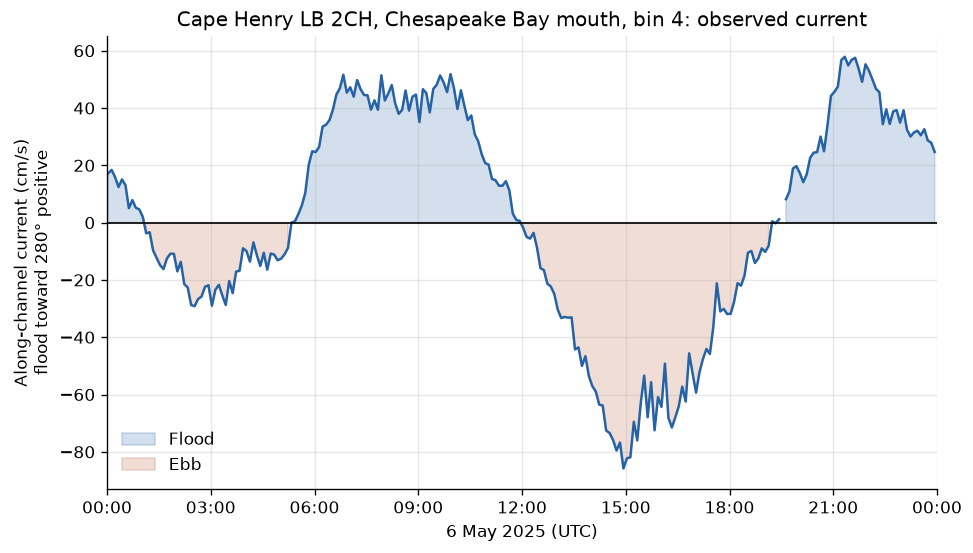

In [6]:
FLOOD = 280  # degrees true, from NOAA's deployment metadata for cb0102
series = frame.reindex(grid)
along = series["Speed"] * np.cos(np.radians(series["Direction"] - FLOOD))
fig, ax = plt.subplots(layout="constrained")
ax.plot(along.index, along, color="#2563a6", linewidth=1.5)
ax.fill_between(along.index, along, 0, where=along > 0, color="#2563a6", alpha=0.2, label="Flood")
ax.fill_between(along.index, along, 0, where=along < 0, color="#b45631", alpha=0.2, label="Ebb")
ax.axhline(0, color="black", linewidth=1)
ax.xaxis.set_major_locator(mdates.HourLocator(byhour=range(0, 24, 3)))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=UTC))
ax.set_xlim(day, day + pd.Timedelta(days=1))
ax.set_xlabel("6 May 2025 (UTC)")
ax.set_ylabel("Along-channel current (cm/s)\nflood toward 280° positive")
ax.set_title("Cape Henry LB 2CH, Chesapeake Bay mouth, bin 4: observed current")
ax.legend(loc="lower left", frameon=False)
plt.show()

In [7]:
direction = frame["Direction"]
flooding = ((direction - FLOOD + 180) % 360 - 180).abs() < 90
phases = (flooding != flooding.shift()).cumsum()
runs = frame.groupby(phases).agg(
    start=("Speed", lambda s: s.index[0]),
    end=("Speed", lambda s: s.index[-1]),
    peak_speed=("Speed", "max"),
    peak_at=("Speed", "idxmax"),
)
runs.insert(0, "phase", flooding.groupby(phases).first().map({True: "flood", False: "ebb"}))
runs = runs[runs["end"] - runs["start"] >= pd.Timedelta("1h")]
for column in ["start", "end", "peak_at"]:
    runs[column] = runs[column].dt.strftime("%H:%M")
print(runs.to_string(index=False))

phase start   end  peak_speed peak_at
flood 00:02 01:02        18.5   00:08
  ebb 01:08 05:20        30.2   02:38
flood 05:26 11:56        56.9   07:14
  ebb 12:02 19:08        85.8   14:56
flood 19:26 23:56        58.1   21:38


The current reversed four times in the day, as the tide at the bay mouth
rose and fell twice, and the two ebbs were far from equal: the early one
peaked at 30.2 cm/s, the afternoon one at 85.8 cm/s at 14:56 UTC, while both
full floods peaked near 57 to 58 cm/s. Around 19:14 and 19:20 the direction
flickered between the two groups at slack water, when speed is near its
minimum and direction means least; the one missing slot, 19:32, is the gap
just after.

## Pin and cite

`verify` checks the cached file against the lockfile's checksum. Keep the
manifest, lockfile, and metadata snapshot with your analysis. CO-OPS may
revise query responses later; a successful `verify` shows the bytes match
what was pinned. The citation below is what a methods section needs, and
`usdata cite dataset.yaml` prints the same.

In [8]:
assert verify(manifest) == []
for citation in cite_lockfile(manifest):
    print(citation.as_text())

noaa:coops-currents
  NOAA National Ocean Service, CO-OPS observed currents, accessed via usdata
  homepage: https://api.tidesandcurrents.noaa.gov/api/prod/
  license: US Government Work (public domain)
  terms: https://tidesandcurrents.noaa.gov/disclaimers.html
  retrieved: 2026-09-24; 1 checksummed asset (6,659 bytes) pinned by usdata 0.26.0
  sources: currents


## What was awkward

- The CSV carries a bin number but no depth. Depth needs dated station
  metadata from a second NOAA service, and even then it describes the
  current deployment, not necessarily the historical day.
- Metric speed is cm/s, not m/s, and the CSV header does not say so; the
  manifest and source URL are the only record of the units.
- The six-minute records here fall two minutes after each six-minute mark,
  and one slot (19:32) is missing. The grid has to be checked before gaps
  are counted.
- Direction is circular. Averaging or connecting angles across 0° and 360°
  misleads, and the flood direction that turns speed and direction into a
  signed current comes from the metadata service, not the data.
- The basic response has no quality flag, so nothing says whether a value
  is preliminary or verified.
- NOAA's documentation mentions hourly currents in one place and says only
  six-minute data exist in another; a probe found `interval=h` ignored, so
  usdata requests only the native interval.